# **BUILDING THE CLASSIFIER MODEL BY APPLYING NLP**
## Steps
*   Scrape reviews from a google playstore apps
*   Text Preprocessing
*   Text clustering
*   Fine tune a pretrained XLNet model
*   Generate Predictions

# Scrape Google Playstore reviews using google-play-scraper and MongoDB







In [ ]:
import pandas as pd
from pprint import pprint
import datetime as dt
from tzlocal import get_localzone
import random
import time

In [ ]:
app_reviews_df = pd.read_csv('playstore_bank_reviews.csv')

In [ ]:
app_reviews_df.shape

(116268, 14)

In [ ]:
app_reviews_df.head(2)

,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id
0,6812ab9b8916e0f32680dea2,8b374d93-15e3-4190-b006-d4eca0219e0d,Sauren Dasgupta,https://play-lh.googleusercontent.com/a-/ALV-U...,User friendly.,3,0,6.5.25,2025-04-29 13:42:00,NaN,NaN,6.5.25,SBI,com.freedomrewardz
1,6812ab9b8916e0f32680dea3,9d0137f8-a72a-47f6-a3bb-0eab585c6aac,Mohit Pandit,https://play-lh.googleusercontent.com/a-/ALV-U...,nice and useful app.,5,0,6.5.25,2025-04-29 13:38:29,NaN,NaN,6.5.25,SBI,com.freedomrewardz


In [ ]:
#splitting the 'at' column into date and time separately

# make string version of original column, call it 'col'
app_reviews_df['col'] = app_reviews_df['at'].astype(str)

# make the new columns using string indexing
app_reviews_df['date'] = app_reviews_df['col'].str[0:11]
app_reviews_df['time'] = app_reviews_df['col'].str[11:20]

# get rid of the extra variable
app_reviews_df.drop('col', axis=1, inplace=True)
app_reviews_df.drop('at', axis=1, inplace=True)

In [ ]:
app_reviews_df['date'] = pd.to_datetime(app_reviews_df['date'])

start_date = '01-01-2019'
end_date = '03-31-2021'

mask = (app_reviews_df['date'] > start_date) & (app_reviews_df['date'] <= end_date)
app_reviews_df = app_reviews_df.loc[mask]

del app_reviews_df['repliedAt']

app_reviews_df.head(2)

,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time
13973,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,Airtel dth operator not available......,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23
13974,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,Nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01


In [ ]:
# you might get some duplicates. To remove duplicates:
app_reviews_df = app_reviews_df.drop_duplicates(subset=['reviewId'])

In [ ]:
#convert the final dataframe into csv
app_reviews_df.to_csv('reviews_final.csv', index=None, header=True)

# Sentiment Analysis

In [ ]:
# Load Required Libraries
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import TextBlob
from textblob import Word

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Read the CSV file
df = pd.read_csv('reviews_final.csv')

In [ ]:
# Text Preprocessing:

# For Text Preprocessing we will use TextBlob Library.TextBlob is built upon NLTK and provides an easy to use interface to the NLTK library.
# Stopwords removal does not yield better results because VADER uses words such as 'but' in calculating the compound score.
# Therefore, we won't be removing stopwords from the text!

from textblob import Word

# Drop rows where content is missing (optional)
df = df.dropna(subset=['content'])

# Ensure all content is treated as string
df['content'] = df['content'].astype(str)

# Lowercasing
df['content'] = df['content'].str.lower()

# Punctuation removal (you can add more cleaning if needed)
df['content'] = df['content'].str.replace(r'[^\w\s]', '', regex=True)

# Lemmatization
df['content'] = df['content'].apply(lambda x: " ".join(Word(word).lemmatize() for word in x.split()))

<ipython-input-11-692ce3952418>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content'] = df['content'].astype(str)
<ipython-input-11-692ce3952418>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content'] = df['content'].str.lower()


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Function for getting the sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
# Generating sentiment for all the sentence present in the dataset:
sentiment_comp=[]
for row in df['content']:

    vs=analyzer.polarity_scores(row)
    sentiment_comp.append(vs)

In [ ]:
# Creating new dataframe with sentiments
df_sentiments=pd.DataFrame(sentiment_comp)
# df_sentiments.head()

In [ ]:
# Merging the sentiments back to reviews dataframe
result_df = pd.concat([df.reset_index(drop=True), df_sentiments], axis=1)

In [ ]:
# Finding percentage of positivity/negativity and adding a column to result_df
percentage_comp = []
for i in result_df['compound']:
    if i > 0:
        percentage = i*100
    elif i < 0:
        percentage = -i*100
    else:
        percentage = " "
    percentage_comp.append(percentage)
result_df['percentage'] = percentage_comp

In [ ]:
# Convert scores into positive, negetive and not defined sentiments using some threshold
result_df["Sentiment"] = result_df["compound"].apply(lambda compound: "positive" if compound > 0 else \
                                              ("negative" if compound < 0 else "not defined"))
result_df.drop(['neg','neu','pos'], axis='columns', inplace=True)
result_df.head(2)

,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time,compound,percentage,Sentiment
0,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,airtel dth operator not available,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23,0.0000,,not defined
1,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01,0.4215,42.15,positive


In [ ]:
result_df.to_csv("reviews_with_sentiments.csv")

# Text Preprocessing

In any machine learning task, cleaning or preprocessing the data is as important as model building. And when it comes to unstructured data like text, this process is even more important.

Some of the common text preprocessing / cleaning steps I have done are:

- Lower casing
- Removal of Punctuations
- Removal of Stopwords
- Stemming

In [ ]:
# import required libraries
import numpy as np
import pandas as pd
import re
import nltk
import spacy
import string
pd.options.mode.chained_assignment = None

In [ ]:
# load the scraped data
sample=pd.read_csv("reviews_with_sentiments.csv")

## Lower Casing
Lower casing is a common text preprocessing technique. The idea is to convert the input text into same casing format so that 'text', 'Text' and 'TEXT' are treated the same way.

This is more helpful for text featurization techniques like frequency, tfidf as it helps to combine the same words together thereby reducing the duplication and get correct counts / tfidf values.



In [ ]:
sample["cleaned_text"] = sample["content"].str.lower()
# sample.head()

## Removal of Punctuations
One another common text preprocessing technique is to remove the punctuations from the text data. This is again a text standardization process that will help to treat 'hurray' and 'hurray!' in the same way.

We also need to carefully choose the list of punctuations to exclude depending on the use case. For example, the string.punctuation in python contains the following punctuation symbols

!"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~`

We can add or remove more punctuations as per our need.



In [ ]:
import string

PUNCT_TO_REMOVE = string.punctuation

def remove_punctuation(text):
    text = str(text)
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

# Handle missing values
sample["cleaned_text"] = sample["cleaned_text"].fillna("")

# Apply punctuation removal
sample["cleaned_text"] = sample["cleaned_text"].apply(remove_punctuation)

In [ ]:
sample.head(2)

,Unnamed: 0,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time,compound,percentage,Sentiment,cleaned_text
0,0,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,airtel dth operator not available,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23,0.0000,,not defined,airtel dth operator not available
1,1,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01,0.4215,42.15,positive,nice


In [ ]:
sample.shape

(40286, 19)

## Removal of stopwords
Stopwords are commonly occuring words in a language like 'the', 'a' and so on. They can be removed from the text most of the times, as they don't provide valuable information for downstream analysis.

These stopword lists are already compiled for different languages and we can safely use them. For example, the stopword list for english language from the nltk package can be seen by running the code below.

In [ ]:
from nltk.corpus import stopwords
", ".join(stopwords.words('english'))

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [ ]:
STOPWORDS = set(stopwords.words('english'))
# exclude the words which you do not want to remove
exclude_words = set(("not", "no"))
new_stop_words = STOPWORDS.difference(exclude_words)

def remove_stopwords(text):
    # custom function to remove the stopwords
    return " ".join([word for word in str(text).split() if word not in new_stop_words])

sample["cleaned_text"] = sample["cleaned_text"].apply(lambda text: remove_stopwords(text))
sample.head(2)

,Unnamed: 0,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time,compound,percentage,Sentiment,cleaned_text
0,0,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,airtel dth operator not available,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23,0.0000,,not defined,airtel dth operator not available
1,1,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01,0.4215,42.15,positive,nice


## Stemming
Stemming is the process of reducing inflected (or sometimes derived) words to their word stem, base or root form (From Wikipedia)

For example, if there are two words in the corpus 'walks' and 'walking', then stemming will stem the suffix to make them walk. But say in another example, we have two words 'console' and 'consoling', the stemmer will remove the suffix and make them consol which is not a proper english word.

There are several type of stemming algorithms available and one of the famous one is porter stemmer which is widely used. We can use nltk package for the same.

In [ ]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

sample["cleaned_text"] = sample["cleaned_text"].apply(lambda text: stem_words(text))
sample.head(2)

,Unnamed: 0,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time,compound,percentage,Sentiment,cleaned_text
0,0,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,airtel dth operator not available,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23,0.0000,,not defined,airtel dth oper not avail
1,1,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01,0.4215,42.15,positive,nice


# Text Clustering

Text clustering is done using tf-idf and k-means clustering and then the final clusteres are formed using n-grams method. In this n-grams technique, you have to make n-grams for the most common words in each cluster and pick only those words which belong to that particular category, basically, the words which are more frequent in that cluster.

Any other method can be used for text clustering depending on different datasets and any desired number of categories can be formed for that dataset.

Here, seven categories were made after clustering and then stored into a csv called 'clustered_data.csv' which is provided in the repository for direct use. It shows the format in which the clustered data was made by doing some data wrangling.


## K means using TFIDF

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorization
tfidf_vect = TfidfVectorizer()
tfidf = tfidf_vect.fit_transform(sample['cleaned_text'].values.astype('U'))

# KMeans clustering (without n_jobs)
model_tfidf = KMeans(n_clusters=7, random_state=99)
model_tfidf.fit(tfidf)

KMeans(n_clusters=7, random_state=99)

In [ ]:
# Understand what kind of words are generated by TF-IDF
terms1 = tfidf_vect.get_feature_names_out()

In [ ]:
# Giving Labels/assigning a cluster to each text
df1 = sample
df1['Tfidf Clus Label'] = model_tfidf.labels_
df1.head(2)

,Unnamed: 0,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,replyContent,appVersion,app_name,app_id,date,time,compound,percentage,Sentiment,cleaned_text,Tfidf Clus Label
0,0,6812ab9c8916e0f326811537,153aab66-4d1f-48f3-967f-e9b6ab7e554d,Manpreet Singh,https://play-lh.googleusercontent.com/a-/ALV-U...,airtel dth operator not available,1,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,23:44:23,0.0000,,not defined,airtel dth oper not avail,3
1,1,6812ab9c8916e0f326811538,3456d0cb-aa52-480f-a2da-d1fffcd15274,Sky-Net Asansol,https://play-lh.googleusercontent.com/a-/ALV-U...,nice,5,0,6.3.8,NaN,6.3.8,SBI,com.freedomrewardz,2021-03-31,12:15:01,0.4215,42.15,positive,nice,1


In [ ]:
# How many points belong to each cluster
df1.groupby(['Tfidf Clus Label'])['content'].count()

,content
Tfidf Clus Label,
0,17241
1,4297
2,1353
3,5919
4,2154
5,779
6,8300


In [ ]:
print("Top terms per cluster:")
order_centroids = model_tfidf.cluster_centers_.argsort()[:, ::-1]

for i in range(7):
    print("Cluster %d:" % i, end='')
    for ind in order_centroids[i, :10]:
        print(' %s' % terms1[ind], end='')
    print()

Top terms per cluster:
Cluster 0: app best super good great servic sbi superb ok experi
Cluster 1: nice app applic experi one aap work servic good sbi
Cluster 2: use app easi nice good point full reward sbi recharg
Cluster 3: not point work recharg app updat reward redeem open time
Cluster 4: excel app servic applic experi sbi work thank good job
Cluster 5: awesom app experi applic sbi love realli thank reward simpli
Cluster 6: good app servic experi job bank excel reward work not


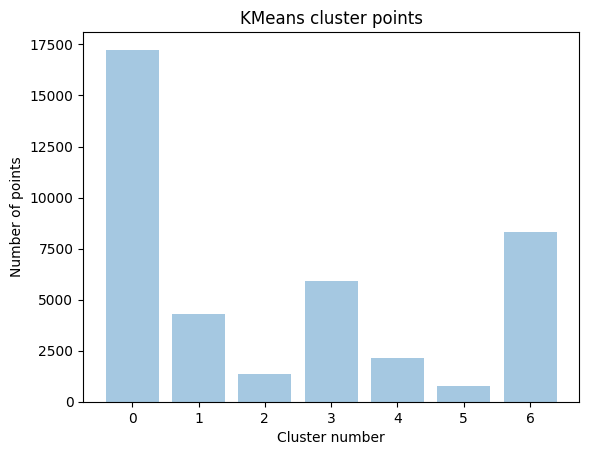

In [ ]:
# how reviews are distributed across 7 clusters
from matplotlib import pyplot as plt
plt.bar([x for x in range(7)], df1.groupby(['Tfidf Clus Label'])['content'].count(), alpha = 0.4)
plt.title('KMeans cluster points')
plt.xlabel("Cluster number")
plt.ylabel("Number of points")
plt.show()

In [ ]:
# Reading a review which belong to each group.
for i in range(7):
    print("5 reviews assigned to cluster ", i)
    print("-" * 70)
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][0]]['content'])
    print('\n')
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][1]]['content'])
    print('\n')
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][2]]['content'])
    print('\n')
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][3]]['content'])
    print('\n')
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][4]]['content'])
    print('\n')
    print(df1.iloc[df1.groupby(['Tfidf Clus Label']).groups[i][5]]['content'])
    print('\n')

    print("_" * 70)

5 reviews assigned to cluster  0
----------------------------------------------------------------------
very nicely built


sbi rewardz is a scam run by sbi you just cant redeem anything lol


iam happy


unpleasant to know that bsnl is not in the reacharge list though it is a nationalised government bank it doesnt support government sector and accepts only private sector and also there are lot of issue while recharging other mobile network whatever may be the technical reason it an unpleasant strategy of sbi


very easy to operate


please shut down sbi reward this is fake promotion


______________________________________________________________________
5 reviews assigned to cluster  1
----------------------------------------------------------------------
nice


nice app


nice app


nice


nice app


nice


______________________________________________________________________
5 reviews assigned to cluster  2
----------------------------------------------------------------------
it 

After making the clusters using TF-IDF and K-means you will get an idea about what are the most common topics/problems which people have spoken about in the reviews. Now, I formed n-grams for the most common and frequent topics in each cluster and formed new cluster of words(my own dictionary of words).

First, seperated the negative reviews and performed this n-grams clustering technique only on the negative reviews and form the dataset in one-hot encoding format.

In [ ]:
# Define clusters
cluster1 = ['recharg','reacharg','richarg','racharg']
cluster2 = ['point','redeem','reedem','reward','redemp','redem']
cluster3 = ['regist','ragist','login','sign','signin','userid','usernam','user name','user id','pissword','passward','log','password','invalid user','user invalid','incorrect user','user incorrect','wrong user','user wrong','user work','enter correct user','say invalid user','password user passwird','user passwird dont','passwird dont know','user passwird dont','ragist','tri login','login say','pleas enter valid','enter correct user','abl sign','app sign','unabl sign','time sign','problem sign','sign say','error sign','unabl signup','unabl signup','sign sign','app unabl signup','poor troubl sign','sign bank employ','app abl sign','abl sign say','sign say sorri','abl sign worst','sign worst app','occur error sign','thrice unabl sign','unabl sign error','sign error messag','signup']
cluster4 = ['survic','costum','custom','servic','repli mail','didnt pick','pick call','mail repli','respons','respond','doesnot responss','responss','responc','poor servic','bad servic','custom care','custom id','worst servic','custom servic','custom support','custom care servic','worst custom servic','custom care number']
cluster5 = ['crash','error','fail','hang','slow','not work','cant open','bug','freeze','problem','install','update','loading','open','stop','network error','server','timeout','disconnect','payment fail','transaction fail','delay','retry','gateway','downtime','broken']

label_cols = [
    'Problem in recharge',
    'Problem in reward/redeem points',
    'Problem in registration/login/username/password',
    'Problem with customer care service',
    'Other complaints',
    'Bad comments',
    'Appreciation'
]

clusters = [cluster1, cluster2, cluster3, cluster4, cluster5]

# Reusable function
def apply_cluster_labels(df, sentiment, appreciation=False):
    df = sample[sample['Sentiment'] == sentiment][['reviewId', 'content', 'cleaned_text']].copy()

    for col_name, cluster_words in zip(label_cols[:5], clusters):
        df[col_name] = '0'
        for word in cluster_words:
            mask = df['cleaned_text'].str.contains(word, na=False)
            df.loc[mask, col_name] = '1'

    if appreciation:
        df['Appreciation'] = df[label_cols[:5]].apply(lambda row: '1' if '1' not in row.values else '0', axis=1)
        df['Bad comments'] = '0'
    else:
        df['Bad comments'] = df[label_cols[:5]].apply(lambda row: '1' if '1' not in row.values else '0', axis=1)
        df['Appreciation'] = '0'

    return df

# Apply
negative = apply_cluster_labels(sample, 'negative')
positive = apply_cluster_labels(sample, 'positive', appreciation=True)
neutral  = apply_cluster_labels(sample, 'neutral')

# Combine and reorder
final_df = pd.concat([negative, positive, neutral], axis=0).reset_index(drop=True)
final_df = final_df[['reviewId', 'content'] + label_cols]

# Preview
final_df.head(2)

,reviewId,content,Problem in recharge,Problem in reward/redeem points,Problem in registration/login/username/password,Problem with customer care service,Other complaints,Bad comments,Appreciation
0,4648114b-b6ec-48c4-991b-6ff07f5d2aa7,sbi rewardz is a scam run by sbi you just cant...,0,1,0,0,0,0,0
1,11b89096-2f8d-4d56-bd7b-9be117d14f5e,unpleasant to know that bsnl is not in the rea...,1,0,0,0,0,0,0


In [ ]:
final_df.columns

Index(['reviewId', 'content', 'Problem in recharge',
       'Problem in reward/redeem points',
       'Problem in registration/login/username/password',
       'Problem with customer care service', 'Other complaints',
       'Bad comments', 'Appreciation'],
      dtype='object')

In [ ]:
# Export
final_df.to_csv('clustered_data.csv', index=False)

# Building the Classifier Model
A pretrained **XLNet model** has been used for classification and then this pretrained XLNet model was fine tuned by training it on the clustered data. And, after preprocessing the data and training the model on this data, a function was formed for getting predictions for a new data along with the probabilities of each label.

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import os
import random
import torch
from torch.nn import BCEWithLogitsLoss
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW  # ✅ fixed here
from transformers import XLNetTokenizer, XLNetModel, XLNetLMHeadModel, XLNetConfig
from transformers import XLNetTokenizerFast
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
%matplotlib inline

## Import Dataset

In [ ]:
df = pd.read_csv('clustered_data.csv')
df.head()

,reviewId,content,Problem in recharge,Problem in reward/redeem points,Problem in registration/login/username/password,Problem with customer care service,Other complaints,Bad comments,Appreciation
0,4648114b-b6ec-48c4-991b-6ff07f5d2aa7,sbi rewardz is a scam run by sbi you just cant...,0,1,0,0,0,0,0
1,11b89096-2f8d-4d56-bd7b-9be117d14f5e,unpleasant to know that bsnl is not in the rea...,1,0,0,0,0,0,0
2,8048e054-4d68-47f2-94dc-da52c9064d7e,poor,0,0,0,0,0,1,0
3,5420cd06-fc90-4887-8ae4-005a8ad67b05,waste app no update in this rewardz of sbi rew...,0,1,0,0,0,0,0
4,75aa65d6-a6db-406f-b44e-35aafcb4265c,worst app not receiving otps,0,0,0,0,0,1,0


In [ ]:
# Split the data:
train, test = train_test_split(df, test_size=0.05)
train.shape, test.shape

((33010, 9), (1738, 9))

In [ ]:
train = train.set_index('reviewId')
train.head(2)

,content,Problem in recharge,Problem in reward/redeem points,Problem in registration/login/username/password,Problem with customer care service,Other complaints,Bad comments,Appreciation
reviewId,,,,,,,,
5a5702fa-1752-4f85-a3df-bfa07c8a2d3b,good,0,0,0,0,0,0,1
92d8b798-3e3c-47e6-810f-e7091b4d09d3,good application,0,0,0,0,0,0,1


In [ ]:
test = test[['reviewId','content']]
test = test.set_index('reviewId')
test.head()

,content
reviewId,
5c0767c0-d8b9-47af-ac7a-2075ac629c5d,ok
5fa4129e-2ed0-44c2-8d34-f16b6d250d9a,great
4de0f45e-3749-43e5-b5ac-c472c2789591,happy
4abf7209-b2ae-4783-aef6-e6cc29c8482d,low amount transferd reward point give please ...
4e5e5f26-f4a0-4b67-b50a-f3cac469aa3e,nice app


In [ ]:
train.shape

(33010, 8)

In [ ]:
test.shape

(1738, 1)

# Preprocess Data

In [ ]:
# tokenize data
tokenizer = XLNetTokenizerFast.from_pretrained('xlnet-base-cased', do_lower_case=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

In [ ]:
train_text_list = train["content"].values
test_text_list = test["content"].values

In [ ]:
def tokenize_inputs(text_list, tokenizer, num_embeddings=512):
    """
    Tokenizes the input text input into ids. Appends the appropriate special
    characters to the end of the text to denote end of sentence. Truncate or pad
    the appropriate sequence length.
    """
    # tokenize the text, then truncate sequence to the desired length minus 2 for
    # the 2 special characters
    tokenized_texts = list(map(lambda t: tokenizer.tokenize(t)[:num_embeddings-2], text_list))
    # convert tokenized text into numeric ids for the appropriate LM
    input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]
    # append special token "<s>" and </s> to end of sentence
    input_ids = [tokenizer.build_inputs_with_special_tokens(x) for x in input_ids]
    # pad sequences
    input_ids = pad_sequences(input_ids, maxlen=num_embeddings, dtype="long", truncating="post", padding="post")
    return input_ids

def create_attn_masks(input_ids):
    """
    Create attention masks to tell model whether attention should be applied to
    the input id tokens. Do not want to perform attention on padding tokens.
    """
    # Create attention masks
    attention_masks = []

    # Create a mask of 1s for each token followed by 0s for padding
    for seq in input_ids:
        seq_mask = [float(i>0) for i in seq]
        attention_masks.append(seq_mask)
    return attention_masks

In [ ]:
# create input id tokens
train_input_ids = tokenize_inputs(train_text_list, tokenizer, num_embeddings=250)
train_input_ids

array([[ 195,    4,    3, ...,    0,    0,    0],
       [ 195, 1479,    4, ...,    0,    0,    0],
       [ 172,  195,    4, ...,    0,    0,    0],
       ...,
       [ 312, 5523,    4, ...,    0,    0,    0],
       [ 195,    4,    3, ...,    0,    0,    0],
       [2712,    4,    3, ...,    0,    0,    0]])

In [ ]:
# create input id tokens
test_input_ids = tokenize_inputs(test_text_list, tokenizer, num_embeddings=250)
test_input_ids

array([[  17, 3518,    4, ...,    0,    0,    0],
       [ 312,    4,    3, ...,    0,    0,    0],
       [1622,    4,    3, ...,    0,    0,    0],
       ...,
       [ 252,    4,    3, ...,    0,    0,    0],
       [2653,    4,    3, ...,    0,    0,    0],
       [2101, 5523,    4, ...,    0,    0,    0]])

In [ ]:
# create attention masks
train_attention_masks = create_attn_masks(train_input_ids)
# train_attention_masks

In [ ]:
# create attention masks
test_attention_masks = create_attn_masks(test_input_ids)
# test_attention_masks

In [ ]:
# add input ids and attention masks to the dataframe
train["features"] = train_input_ids.tolist()
train["masks"] = train_attention_masks

test["features"] = test_input_ids.tolist()
test["masks"] = test_attention_masks

In [ ]:
train.head(2)

,content,Problem in recharge,Problem in reward/redeem points,Problem in registration/login/username/password,Problem with customer care service,Other complaints,Bad comments,Appreciation,features,masks
reviewId,,,,,,,,,,
5a5702fa-1752-4f85-a3df-bfa07c8a2d3b,good,0,0,0,0,0,0,1,"[195, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
92d8b798-3e3c-47e6-810f-e7091b4d09d3,good application,0,0,0,0,0,0,1,"[195, 1479, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
test.head(2)

,content,features,masks
reviewId,,,
5c0767c0-d8b9-47af-ac7a-2075ac629c5d,ok,"[17, 3518, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5fa4129e-2ed0-44c2-8d34-f16b6d250d9a,great,"[312, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Train, Valid Split

In [ ]:
# split into train and valid
train, valid = train_test_split(train, test_size=0.2, random_state=42)

In [ ]:
X_train = train["features"].values.tolist()
X_valid = valid["features"].values.tolist()

train_masks = train["masks"].values.tolist()
valid_masks = valid["masks"].values.tolist()

label_cols = ['Problem in recharge','Problem in reward/redeem points','Problem in registration/login/username/password','Problem with customer care service','Other complaints','Bad comments','Appreciation']
Y_train = train[label_cols].values.tolist()
Y_valid = valid[label_cols].values.tolist()

# Create Dataloaders

In [ ]:
# create dataloaders
# Convert all of our input ids and attention masks into
# torch tensors, the required datatype for our model

X_train = torch.tensor(X_train)
X_valid = torch.tensor(X_valid)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_valid = torch.tensor(Y_valid, dtype=torch.float32)

train_masks = torch.tensor(train_masks, dtype=torch.long)
valid_masks = torch.tensor(valid_masks, dtype=torch.long)

In [ ]:
# Batch size for training
batch_size = 16

# Create an iterator of our data with torch DataLoader.
train_data = TensorDataset(X_train, train_masks, Y_train)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data,\
                              sampler=train_sampler,\
                              batch_size=batch_size)

validation_data = TensorDataset(X_valid, valid_masks, Y_valid)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data,\
                                   sampler=validation_sampler,\
                                   batch_size=batch_size)

In [ ]:
def train(model, num_epochs,\
          optimizer,\
          train_dataloader, valid_dataloader,\
          model_save_path,\
          train_loss_set=[], valid_loss_set = [],\
          lowest_eval_loss=None, start_epoch=0,\
          device="cpu"
          ):
  """
  Train the model and save the model with the lowest validation loss
  """

  model.to(device)

  # trange is a tqdm wrapper around the normal python range
  for i in trange(num_epochs, desc="Epoch"):
    # if continue training from saved model
    actual_epoch = start_epoch + i

    # Training

    # Set our model to training mode (as opposed to evaluation mode)
    model.train()

    # Tracking variables
    tr_loss = 0
    num_train_samples = 0

    # Train the data for one epoch
    for step, batch in enumerate(train_dataloader):
      # Add batch to GPU
      batch = tuple(t.to(device) for t in batch)
      # Unpack the inputs from our dataloader
      b_input_ids, b_input_mask, b_labels = batch
      # Clear out the gradients (by default they accumulate)
      optimizer.zero_grad()
      # Forward pass
      loss = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
      # store train loss
      tr_loss += loss.item()
      num_train_samples += b_labels.size(0)
      # Backward pass
      loss.backward()
      # Update parameters and take a step using the computed gradient
      optimizer.step()
      #scheduler.step()

    # Update tracking variables
    epoch_train_loss = tr_loss/num_train_samples
    train_loss_set.append(epoch_train_loss)

    print("Train loss: {}".format(epoch_train_loss))

    # Validation

    # Put model in evaluation mode to evaluate loss on the validation set
    model.eval()

    # Tracking variables
    eval_loss = 0
    num_eval_samples = 0

    # Evaluate data for one epoch
    for batch in valid_dataloader:
      # Add batch to GPU
      batch = tuple(t.to(device) for t in batch)
      # Unpack the inputs from our dataloader
      b_input_ids, b_input_mask, b_labels = batch
      # Telling the model not to compute or store gradients,
      # saving memory and speeding up validation
      with torch.no_grad():
        # Forward pass, calculate validation loss
        loss = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        # store valid loss
        eval_loss += loss.item()
        num_eval_samples += b_labels.size(0)

    epoch_eval_loss = eval_loss/num_eval_samples
    valid_loss_set.append(epoch_eval_loss)

    print("Valid loss: {}".format(epoch_eval_loss))

    if lowest_eval_loss == None:
      lowest_eval_loss = epoch_eval_loss
      # save model
      save_model(model, model_save_path, actual_epoch,\
                 lowest_eval_loss, train_loss_set, valid_loss_set)
    else:
      if epoch_eval_loss < lowest_eval_loss:
        lowest_eval_loss = epoch_eval_loss
        # save model
        save_model(model, model_save_path, actual_epoch,\
                   lowest_eval_loss, train_loss_set, valid_loss_set)
    print("\n")

  return model, train_loss_set, valid_loss_set


def save_model(model, save_path, epochs, lowest_eval_loss, train_loss_hist, valid_loss_hist):
  """
  Save the model to the path directory provided
  """
  model_to_save = model.module if hasattr(model, 'module') else model
  checkpoint = {'epochs': epochs, \
                'lowest_eval_loss': lowest_eval_loss,\
                'state_dict': model_to_save.state_dict(),\
                'train_loss_hist': train_loss_hist,\
                'valid_loss_hist': valid_loss_hist
               }
  torch.save(checkpoint, save_path)
  print("Saving model at epoch {} with validation loss of {}".format(epochs,\
                                                                     lowest_eval_loss))
  return

def load_model(save_path):
  """
  Load the model from the path directory provided
  """
  checkpoint = torch.load(save_path)
  model_state_dict = checkpoint['state_dict']
  model = XLNetForMultiLabelSequenceClassification(num_labels=model_state_dict["classifier.weight"].size()[0])
  model.load_state_dict(model_state_dict)

  epochs = checkpoint["epochs"]
  lowest_eval_loss = checkpoint["lowest_eval_loss"]
  train_loss_hist = checkpoint["train_loss_hist"]
  valid_loss_hist = checkpoint["valid_loss_hist"]

  return model, epochs, lowest_eval_loss, train_loss_hist, valid_loss_hist

# Train Model from Scratch

In [ ]:
# train model from scratch

torch.cuda.empty_cache()

In [ ]:
#config = XLNetConfig()

class XLNetForMultiLabelSequenceClassification(torch.nn.Module):

  def __init__(self, num_labels=2):
    super(XLNetForMultiLabelSequenceClassification, self).__init__()
    self.num_labels = num_labels
    self.xlnet = XLNetModel.from_pretrained('xlnet-base-cased')
    self.classifier = torch.nn.Linear(768, num_labels)

    torch.nn.init.xavier_normal_(self.classifier.weight)

  def forward(self, input_ids, token_type_ids=None,\
              attention_mask=None, labels=None):
    # last hidden layer
    last_hidden_state = self.xlnet(input_ids=input_ids,\
                                   attention_mask=attention_mask,\
                                   token_type_ids=token_type_ids)
    # pool the outputs into a mean vector
    mean_last_hidden_state = self.pool_hidden_state(last_hidden_state)
    logits = self.classifier(mean_last_hidden_state)

    if labels is not None:
      loss_fct = BCEWithLogitsLoss()
      loss = loss_fct(logits.view(-1, self.num_labels),\
                      labels.view(-1, self.num_labels))
      return loss
    else:
      return logits

  def freeze_xlnet_decoder(self):
    """
    Freeze XLNet weight parameters. They will not be updated during training.
    """
    for param in self.xlnet.parameters():
      param.requires_grad = False

  def unfreeze_xlnet_decoder(self):
    """
    Unfreeze XLNet weight parameters. They will be updated during training.
    """
    for param in self.xlnet.parameters():
      param.requires_grad = True

  def pool_hidden_state(self, last_hidden_state):
    """
    Pool the output vectors into a single mean vector
    """
    last_hidden_state = last_hidden_state[0]
    mean_last_hidden_state = torch.mean(last_hidden_state, 1)
    return mean_last_hidden_state

model = XLNetForMultiLabelSequenceClassification(num_labels=len(Y_train[0]))

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

In [ ]:
# import drive in colab to get a model save path
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# training..
num_epochs=3

model_save_name = 'classifier_model1.pt'
model_save_path = F"/content/gdrive/My Drive/{model_save_name}"
model, train_loss_set, valid_loss_set = train(model=model,\
                                              num_epochs=num_epochs,\
                                              optimizer=optimizer,\
                                              train_dataloader=train_dataloader,\
                                              valid_dataloader=validation_dataloader,\
                                              model_save_path=model_save_path,\
                                              device="cuda")

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Train loss: 0.0032816314267939107
Valid loss: 0.0008468155780790712


Epoch:  33%|███▎      | 1/3 [34:25<1:08:51, 2065.74s/it]

Saving model at epoch 0 with validation loss of 0.0008468155780790712


Train loss: 0.0007421546165005617
Valid loss: 0.0006699462010248416


Epoch:  67%|██████▋   | 2/3 [1:08:53<34:26, 2066.68s/it]

Saving model at epoch 1 with validation loss of 0.0006699462010248416


Train loss: 0.0004833473241484217
Valid loss: 0.0005893453688440142


Epoch: 100%|██████████| 3/3 [1:43:19<00:00, 2066.50s/it]

Saving model at epoch 2 with validation loss of 0.0005893453688440142




# Train Model From Previous Checkpoint

In [ ]:
# train model from previous checkpoint
model_save_name = 'classifier_model1.pt'
model_save_path = F"/content/gdrive/My Drive/{model_save_name}"
model, start_epoch, lowest_eval_loss, train_loss_hist, valid_loss_hist = load_model(model_save_path)

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

In [ ]:
num_epochs=3
model, train_loss_set, valid_loss_set = train(model=model,\
                                              num_epochs=num_epochs,\
                                              optimizer=optimizer,\
                                              train_dataloader=train_dataloader,\
                                              valid_dataloader=validation_dataloader,\
                                              model_save_path=model_save_path,\
                                              train_loss_set=train_loss_hist,\
                                              valid_loss_set=valid_loss_hist,\
                                              lowest_eval_loss=lowest_eval_loss,\
                                              start_epoch=start_epoch,\
                                              device="cuda")

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

Train loss: 0.00034052273118117784


Epoch:  33%|███▎      | 1/3 [34:11<1:08:23, 2051.76s/it]

Valid loss: 0.0006374987495182398


Train loss: 0.00022033691284370504


Epoch:  67%|██████▋   | 2/3 [1:08:30<34:16, 2056.15s/it]

Valid loss: 0.0007051953466529258


Train loss: 0.00021507048217680628
Valid loss: 0.0005329301930666368


Epoch: 100%|██████████| 3/3 [1:42:51<00:00, 2057.21s/it]

Saving model at epoch 4 with validation loss of 0.0005329301930666368




In [ ]:
# save the model
torch. save(model. state_dict(), model_save_path)

# Get Predictions

In [ ]:
import math

In [ ]:
# get predictions
def generate_predictions(model, df, num_labels, device="cpu", batch_size=32):
  num_iter = math.ceil(df.shape[0]/batch_size)

  pred_probs = np.array([]).reshape(0, num_labels)

  model.to(device)
  model.eval()

  for i in range(num_iter):
    df_subset = df.iloc[i*batch_size:(i+1)*batch_size,:]
    X = df_subset["features"].values.tolist()
    masks = df_subset["masks"].values.tolist()
    X = torch.tensor(X)
    masks = torch.tensor(masks, dtype=torch.long)
    X = X.to(device)
    masks = masks.to(device)
    with torch.no_grad():
      logits = model(input_ids=X, attention_mask=masks)
      logits = logits.sigmoid().detach().cpu().numpy()
      pred_probs = np.vstack([pred_probs, logits])

  return pred_probs

In [ ]:
num_labels = len(label_cols)
pred_probs = generate_predictions(model, test, num_labels, device="cuda", batch_size=32)
pred_probs = np.round(pred_probs, 3)
# pred_probs

In [ ]:
label_cols = ['Problem in recharge','Problem in reward/redeem points','Problem in registration/login/username/password','Problem with customer care service','Other complaints','Bad comments','Appreciation']

test['Problem in recharge'] = pred_probs[:,0]
test['Problem in reward/redeem points'] = pred_probs[:,1]
test['Problem in registration/login/username/password'] = pred_probs[:,2]
test['Problem with customer care service'] = pred_probs[:,3]
test['Other complaints'] = pred_probs[:,4]
test['Bad comments'] = pred_probs[:,5]
test['Appreciation'] = pred_probs[:,6]

In [ ]:
test.head()

,content,features,masks,Problem in recharge,Problem in reward/redeem points,Problem in registration/login/username/password,Problem with customer care service,Other complaints,Bad comments,Appreciation
reviewId,,,,,,,,,,
5c0767c0-d8b9-47af-ac7a-2075ac629c5d,ok,"[17, 3518, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,1.0
5fa4129e-2ed0-44c2-8d34-f16b6d250d9a,great,"[312, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,1.0
4de0f45e-3749-43e5-b5ac-c472c2789591,happy,"[1622, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,1.0
4abf7209-b2ae-4783-aef6-e6cc29c8482d,low amount transferd reward point give please ...,"[599, 1065, 2457, 66, 8614, 424, 371, 1282, 16...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.0,1.0,0.0,0.0,0.0,0.0,0.0
4e5e5f26-f4a0-4b67-b50a-f3cac469aa3e,nice app,"[2101, 5523, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# test.to_csv('xlnet_classifier.csv')

# Get results for a single comment

In [ ]:
comment = "recharge was bad and the customer care did not respond and the app was not working"

In [ ]:
data = [[comment]]
df1 = pd.DataFrame(data, columns = ['content'])
df1_text_list = df1["content"].values
df1_input_ids = tokenize_inputs(df1_text_list, tokenizer, num_embeddings=250)
df1_attention_masks = create_attn_masks(df1_input_ids)
df1["features"] = df1_input_ids.tolist()
df1["masks"] = df1_attention_masks
num_labels = len(label_cols)
pred_probs = generate_predictions(model, df1, num_labels, device="cuda", batch_size=1)
pred_probs = np.round(pred_probs, 3)
probsList = [ item for elem in pred_probs for item in elem]
probsList

[np.float64(1.0),
 np.float64(0.0),
 np.float64(0.002),
 np.float64(1.0),
 np.float64(0.999),
 np.float64(0.0),
 np.float64(0.0)]

In [ ]:
data = [[comment]]
df1 = pd.DataFrame(data, columns = ['content'])
df1_text_list = df1["content"].values
df1_input_ids = tokenize_inputs(df1_text_list, tokenizer, num_embeddings=250)
df1_attention_masks = create_attn_masks(df1_input_ids)
df1["features"] = df1_input_ids.tolist()
df1["masks"] = df1_attention_masks
num_labels = len(label_cols)
pred_probs = generate_predictions(model, df1, num_labels, device="cuda", batch_size=1)
pred_probs = np.round(pred_probs, 3)
probsList = [ item for elem in pred_probs for item in elem]
probsList

[0.999, 0.001, 0.0, 1.0, 0.932, 0.0, 0.001]

In [ ]:
THRESHOLD = 0.5
if probsList[0] < THRESHOLD and probsList[1] < THRESHOLD and probsList[2] < THRESHOLD and probsList[
    3] < THRESHOLD and probsList[4] < THRESHOLD and probsList[5] < THRESHOLD and probsList[6] < THRESHOLD:
    st.subheader("Your text does not belong to any category!")
else:
    for label, prediction in zip(label_cols, probsList):
        if prediction < THRESHOLD:
            continue
        print(f"{label}: {prediction}")

Problem in recharge: 1.0
Problem with customer care service: 1.0
Other complaints: 0.999


In [ ]:
THRESHOLD = 0.5
if probsList[0] < THRESHOLD and probsList[1] < THRESHOLD and probsList[2] < THRESHOLD and probsList[
    3] < THRESHOLD and probsList[4] < THRESHOLD and probsList[5] < THRESHOLD and probsList[6] < THRESHOLD:
    st.subheader("Your text does not belong to any category!")
else:
    for label, prediction in zip(label_cols, probsList):
        if prediction < THRESHOLD:
            continue
        print(f"{label}: {prediction}")

Problem in recharge: 0.999
Problem with customer care service: 1.0
Other complaints: 0.932
